# WEDNESDAY 21ST JANUARY, 2026
# UNSUPERVISED LEARNING
## HIERACHY CLUSTERING

### Step 1: Load the data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


### Step 2: Check cluster groups

In [3]:
x= df[['Age','Income($)']]
x

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [4]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        22 non-null     int64
 1   Income($)  22 non-null     int64
dtypes: int64(2)
memory usage: 484.0 bytes


### Step 3: Scaling
- fit(x)
- The scaler looks at your data x and computes:

- Mean of each column

- Standard deviation of each column

- transform(x)
- It converts each value using:

- So every feature now has:

- Mean ≈ 0

- Standard deviation ≈ 1

- x_scaled


- Displays the scaled version of your original data.

- Why this is important (especially for KMeans & Hierarchical)

- Because your features (e.g. Age vs Income) are on very different scales:

Age: 20–70

Income: 10,000–300,000

- Without scaling, distance-based algorithms think Income is more important.
- With scaling, both features contribute equally to clustering.

So this step makes your clustering mathematically fair and accurate.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-1.35605536, -0.48068427],
       [-1.00915747, -0.01015907],
       [-1.00915747, -0.69242061],
       [-1.18260641, -0.71594687],
       [ 1.24567876,  1.40141653],
       [ 0.72533193,  1.51904783],
       [ 1.07222982,  1.63667914],
       [ 0.55188299,  1.68373166],
       [ 0.20498511,  1.54257409],
       [ 0.03153617,  0.93089133],
       [ 0.37843405,  1.09557515],
       [-1.5295043 , -1.06884077],
       [-1.35605536, -0.99826199],
       [-1.18260641, -0.92768321],
       [-1.00915747, -0.9629726 ],
       [-0.48881065, -0.88063069],
       [ 0.89878087, -0.59831557],
       [ 1.07222982, -0.64536809],
       [ 1.4191277 , -0.62184183],
       [ 0.72533193, -0.24542167],
       [ 1.07222982, -0.19836915],
       [ 0.72533193, -0.76299939]])

### Scatterplot

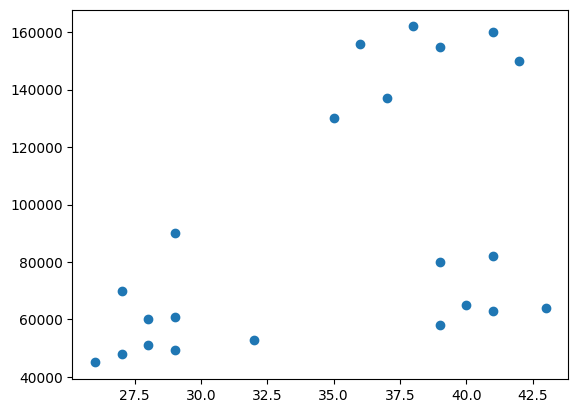

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x.Age, x['Income($)'])

### Step 4: Dendrogram
- we use sch from scipy sch(scipy.cluster.hierachy)
- For three long lines we have three clusters

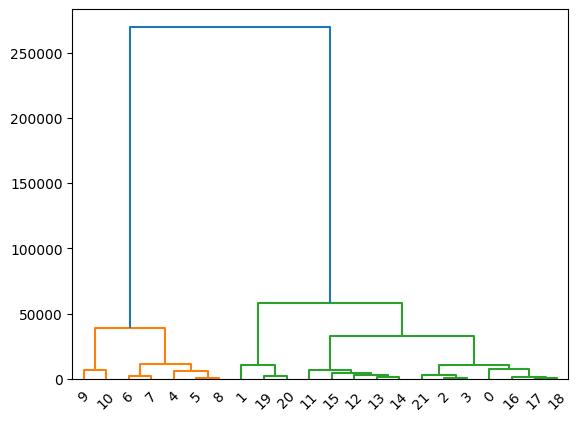

In [10]:
dendrogram = sch.dendrogram(sch.linkage(x, method ='ward'))


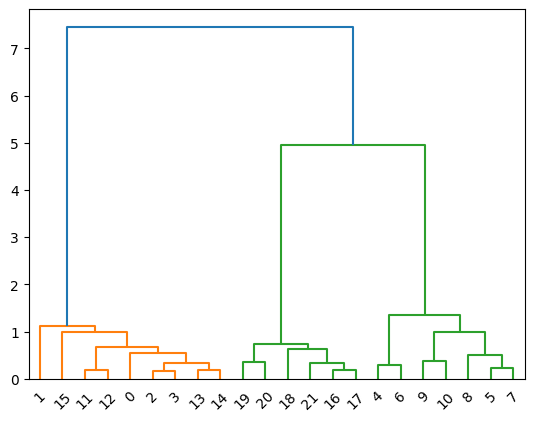

In [9]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(x_scaled, method ='ward'))

### Agglomerative clustering
- A type of hierachial clustering that starts with each datapoint as its own cluster.
- fit → the model learns the cluster structure from your scaled data

- predict → it assigns each data point to a cluster (0, 1, or 2)

In [11]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

y_pred = hc.fit_predict(x_scaled)
y_pred

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2])

In [12]:
df['Cluster'] = y_pred
df

,Name,Age,Income($),Cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0
5,Gautam,39,155000,0
6,David,41,160000,0
7,Andrea,38,162000,0
8,Brad,36,156000,0
9,Angelina,35,130000,0


### Cluster plots

In [13]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

C:\Users\Sally\AppData\Local\Temp\ipykernel_3092\1613617529.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Age')

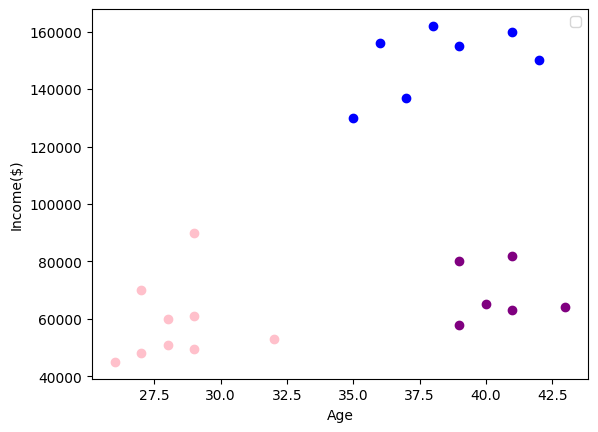

In [14]:
plt.scatter(df1['Age'], df1['Income($)'], color='blue')
plt.scatter(df2['Age'], df2['Income($)'], color='pink')
plt.scatter(df3['Age'], df3['Income($)'], color='purple')

plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')

### Assignment
- 